In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("insurance.csv")
df.head()
df.info()
df.isnull().sum()
df.tail()
df.nunique()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


(1338, 7)

In [3]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


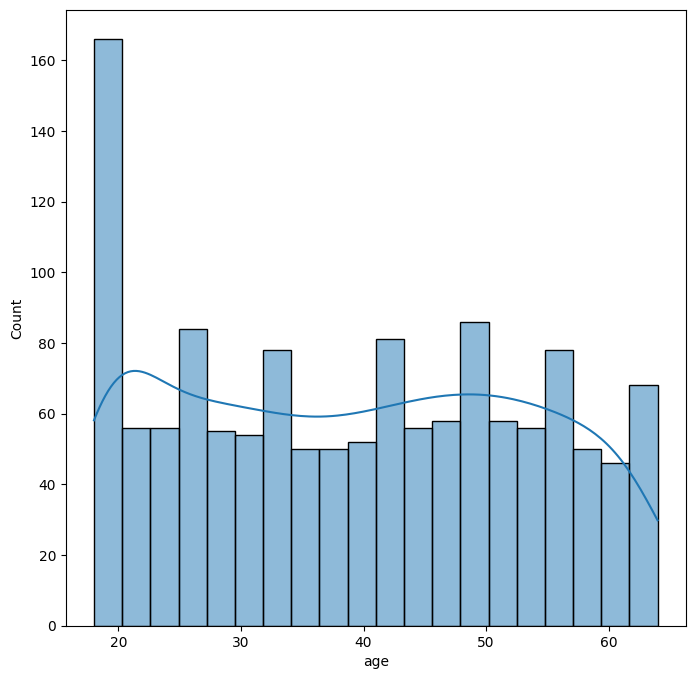

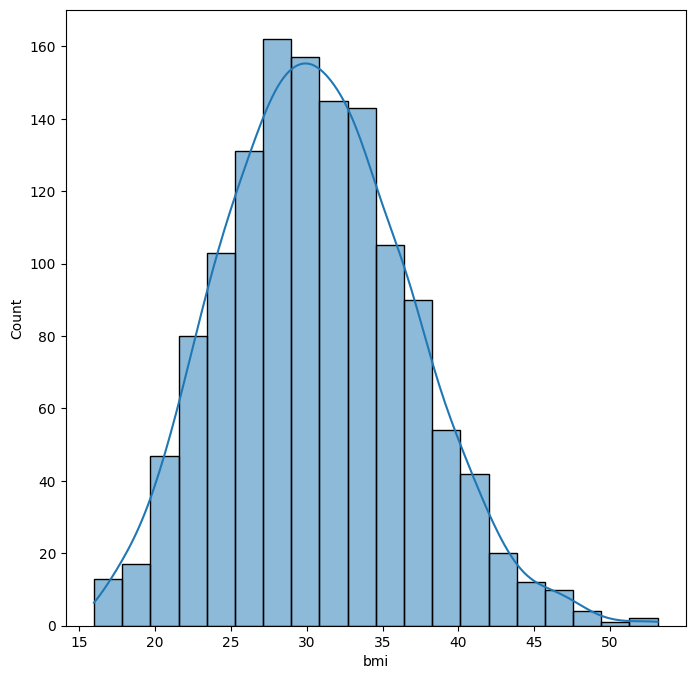

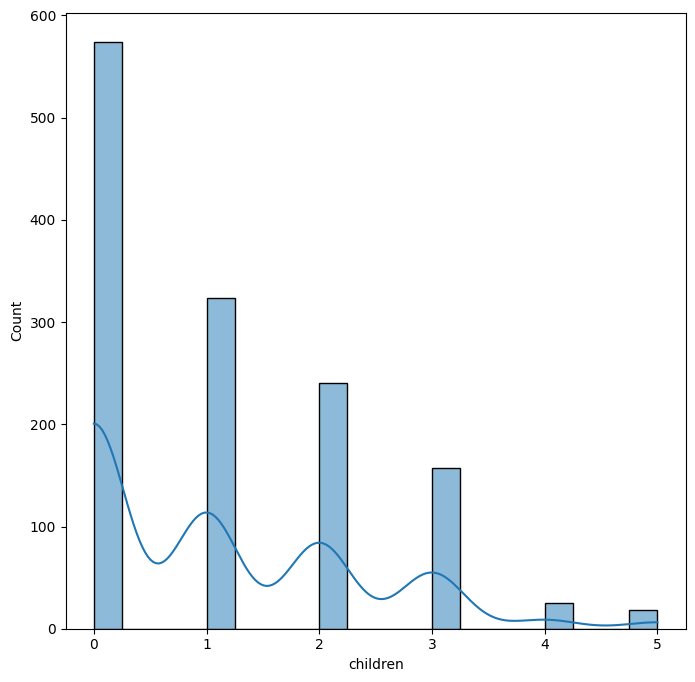

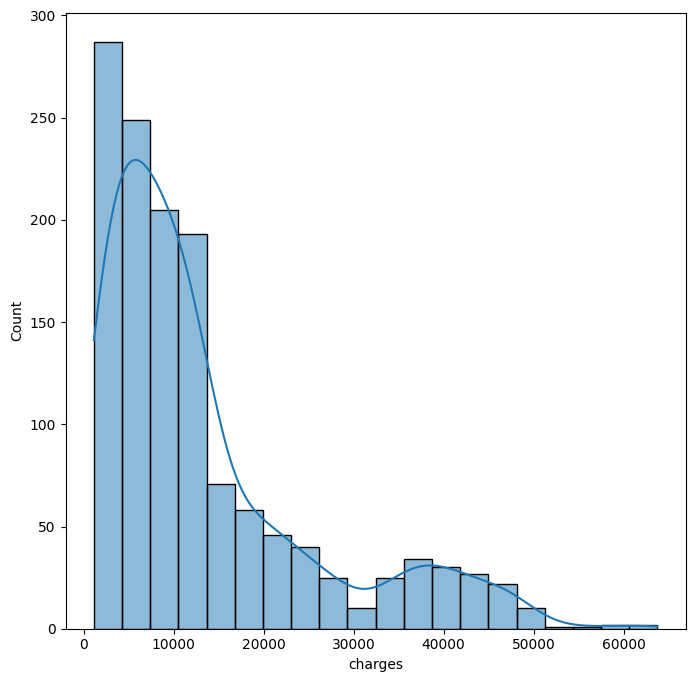

In [4]:
numeric_col=["age","bmi","children","charges"]

for col in numeric_col:
    fig=plt.subplots(figsize=(8,8))
    sns.histplot(df[col],bins=20,kde=True) #kernel denisty curve

<Axes: xlabel='children', ylabel='count'>

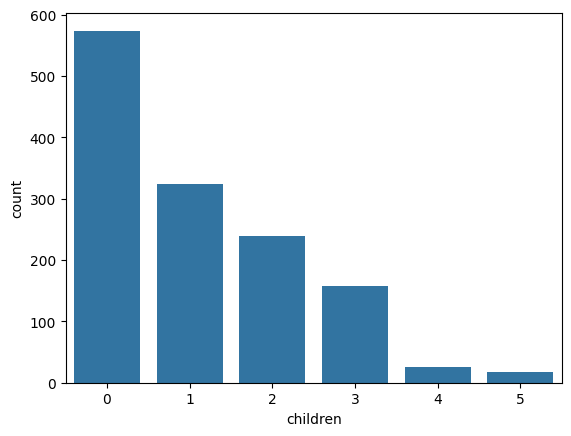

In [5]:
sns.countplot(
    x=df['children'],
)

<Axes: xlabel='smoker', ylabel='count'>

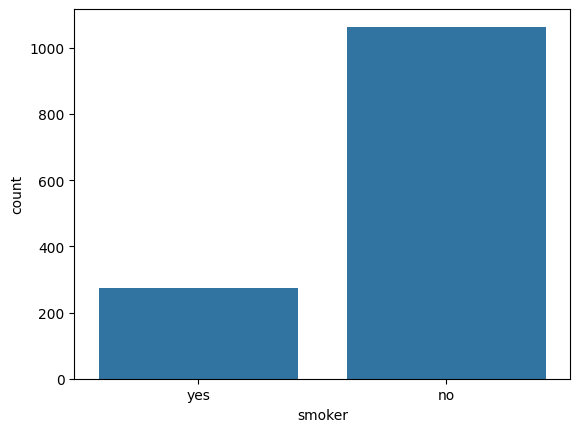

In [6]:
sns.countplot(
    x=df['smoker']
)

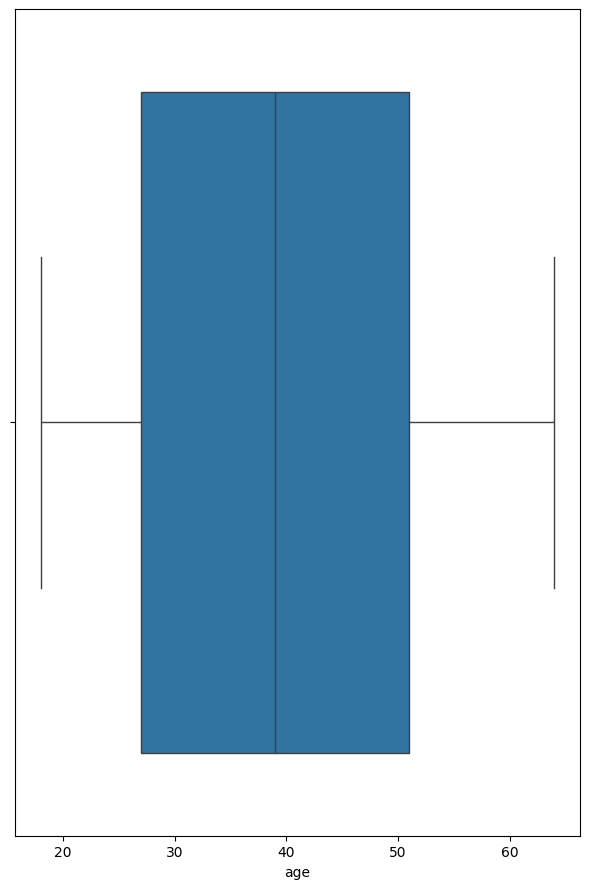

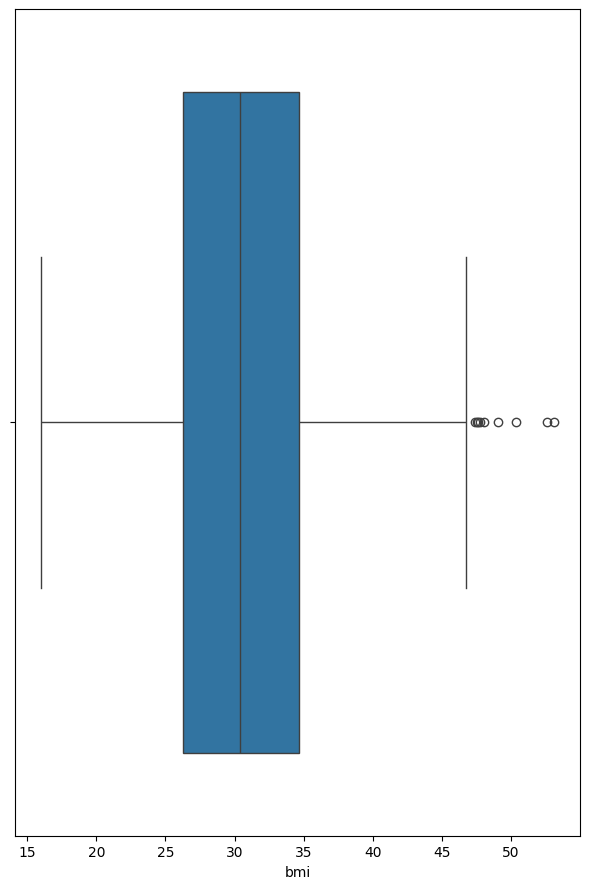

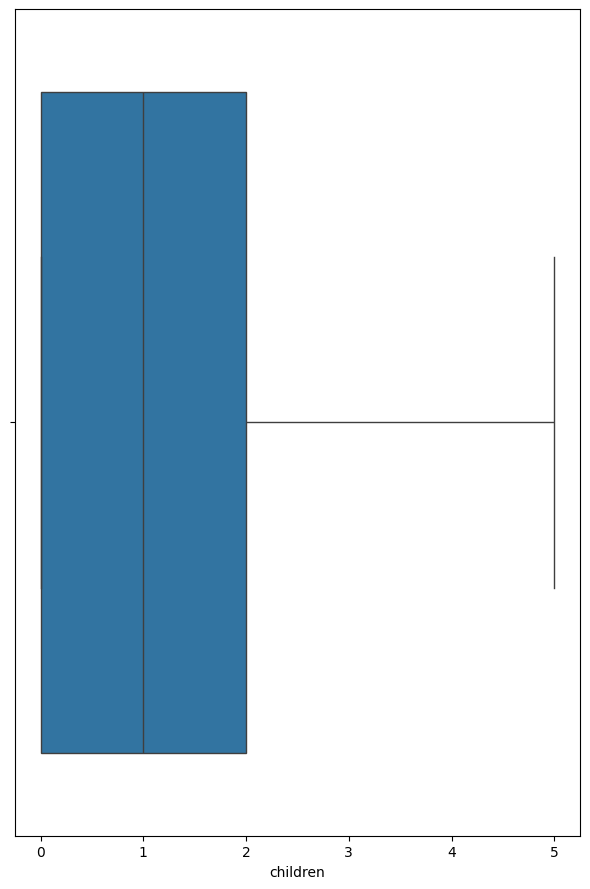

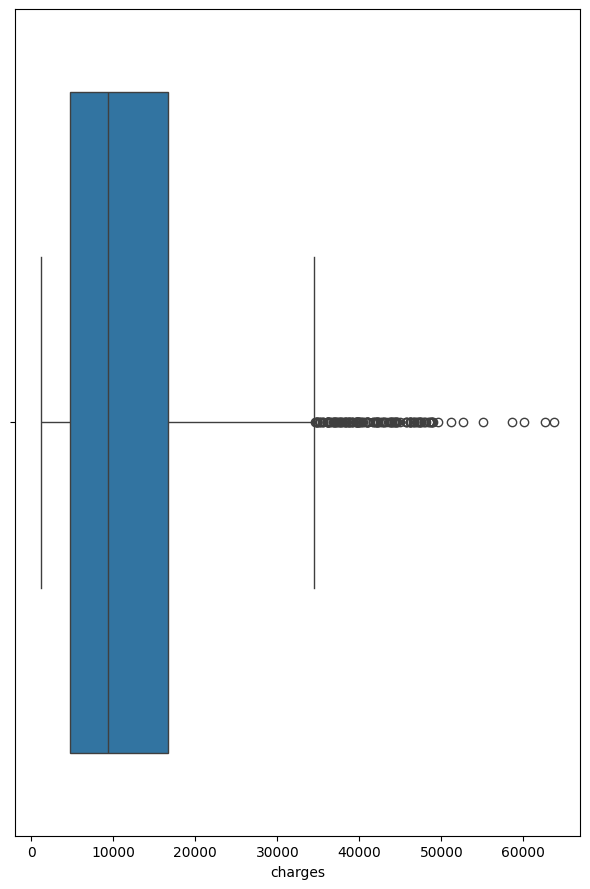

In [7]:
for col in numeric_col:
    fig=plt.subplots(figsize=(6,9))
    sns.boxplot(
        x=df[col],
        
    )
    plt.tight_layout()

<Axes: >

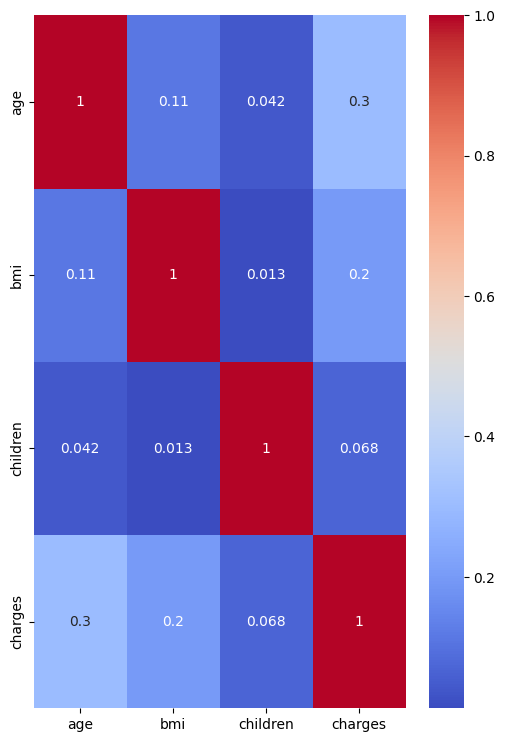

In [8]:
plt.figure(figsize=(6,9))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

In [9]:
df_clean=df.copy()
df_clean.drop_duplicates(inplace=True)
df_clean.shape

(1337, 7)

In [10]:
df_clean.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   str    
 5   region    1337 non-null   str    
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 83.6 KB


In [12]:
df_clean['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [13]:
#label encoding
g_map={"male":0,"female":1}
df_clean['sex']=df_clean['sex'].map(g_map)

In [14]:
if 'sex' in df_clean.columns:
    df_clean['isFemale']=df_clean['sex']  
    df_clean.drop("sex",axis=1,inplace=True)

In [15]:
df_clean.head()

,age,bmi,children,smoker,region,charges,isFemale
0,19,27.900,0,yes,southwest,16884.92400,1
1,18,33.770,1,no,southeast,1725.55230,0
2,28,33.000,3,no,southeast,4449.46200,0
3,33,22.705,0,no,northwest,21984.47061,0
4,32,28.880,0,no,northwest,3866.85520,0


In [16]:
df_clean['smoker'].value_counts()
is_smoker={"yes":1,"no":0}

df_clean['smoker']=df_clean['smoker'].map(is_smoker)
df_clean.head()

if 'smoker' in df_clean.columns:
    df_clean['isSmoker']=df_clean['smoker']
    df_clean.drop('smoker',axis=1,inplace=True)

In [17]:
df_clean.head()
df_clean['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [18]:
df_clean=pd.get_dummies(df_clean,columns=["region"],drop_first=True)
df_clean.head()


,age,bmi,children,charges,isFemale,isSmoker,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,1,False,False,True
1,18,33.770,1,1725.55230,0,0,False,True,False
2,28,33.000,3,4449.46200,0,0,False,True,False
3,33,22.705,0,21984.47061,0,0,True,False,False
4,32,28.880,0,3866.85520,0,0,True,False,False


In [19]:
df_clean.shape

df_clean['isSmoker']=df_clean['isSmoker'].astype('int')
df_clean.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   bmi               1337 non-null   float64
 2   children          1337 non-null   int64  
 3   charges           1337 non-null   float64
 4   isFemale          1337 non-null   int64  
 5   isSmoker          1337 non-null   int64  
 6   region_northwest  1337 non-null   bool   
 7   region_southeast  1337 non-null   bool   
 8   region_southwest  1337 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 77.0 KB


<Axes: xlabel='bmi', ylabel='Count'>

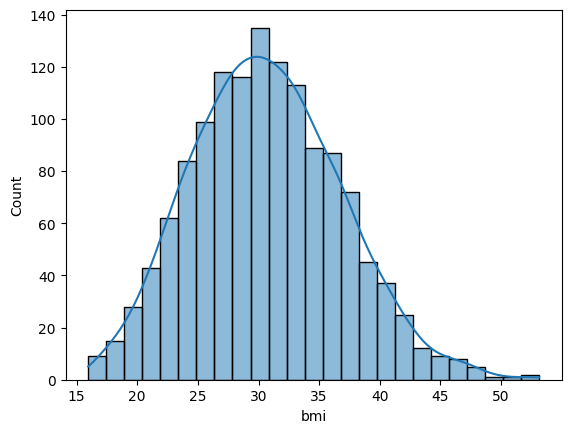

In [20]:
#feature engineering

sns.histplot(
    df_clean['bmi'],
    kde=True,
    
)

In [21]:
df_clean['bmi_category']=pd.cut(
    df_clean['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')], #float('inf') is infinity
    labels=['UnderWeight','Normal','OverWeight','Obese']
) #continous numeric data into category bins

In [22]:
df_clean

,age,bmi,children,charges,isFemale,isSmoker,region_northwest,region_southeast,region_southwest,bmi_category
0,19,27.900,0,16884.92400,1,1,False,False,True,OverWeight
1,18,33.770,1,1725.55230,0,0,False,True,False,Obese
2,28,33.000,3,4449.46200,0,0,False,True,False,Obese
3,33,22.705,0,21984.47061,0,0,True,False,False,Normal
4,32,28.880,0,3866.85520,0,0,True,False,False,OverWeight
...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,0,0,True,False,False,Obese
1334,18,31.920,0,2205.98080,1,0,False,False,False,Obese
1335,18,36.850,0,1629.83350,1,0,False,True,False,Obese
1336,21,25.800,0,2007.94500,1,0,False,False,True,OverWeight


In [23]:
df_clean=pd.get_dummies(df_clean,columns=['bmi_category'])
df_clean.head()

,age,bmi,children,charges,isFemale,isSmoker,region_northwest,region_southeast,region_southwest,bmi_category_UnderWeight,bmi_category_Normal,bmi_category_OverWeight,bmi_category_Obese
0,19,27.900,0,16884.92400,1,1,False,False,True,False,False,True,False
1,18,33.770,1,1725.55230,0,0,False,True,False,False,False,False,True
2,28,33.000,3,4449.46200,0,0,False,True,False,False,False,False,True
3,33,22.705,0,21984.47061,0,0,True,False,False,False,True,False,False
4,32,28.880,0,3866.85520,0,0,True,False,False,False,False,True,False


np.float64(30.66345175766642)

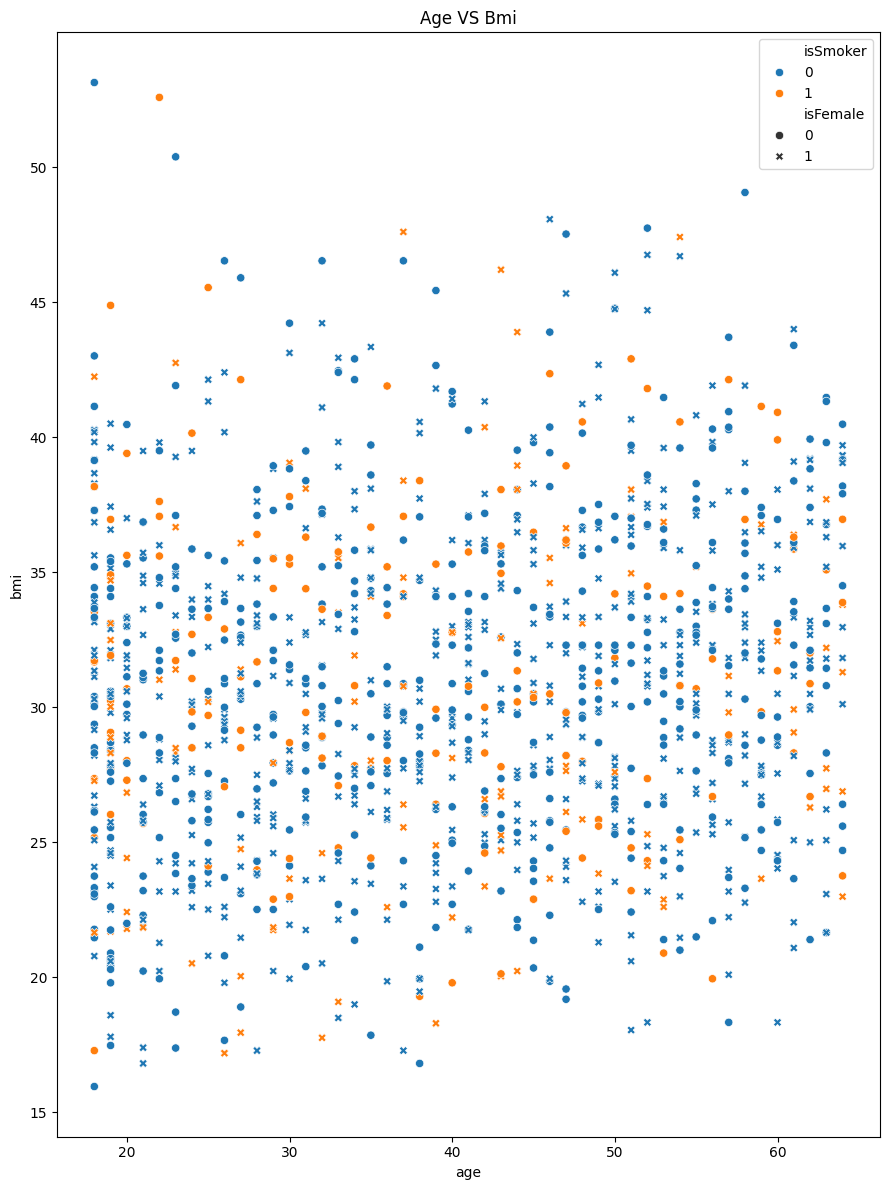

In [24]:
plt.figure(figsize=(9,12))
sns.scatterplot(
    data=df_clean,
    x='age',
    y='bmi',
    hue='isSmoker',
    style='isFemale',
   
)

plt.title('Age VS Bmi')
plt.tight_layout()
plt.legend(loc="upper right")
df_clean['bmi'].mean()


(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5]),
 [Text(0, 0.5, 'age'),
  Text(0, 1.5, 'bmi'),
  Text(0, 2.5, 'children'),
  Text(0, 3.5, 'charges'),
  Text(0, 4.5, 'isFemale'),
  Text(0, 5.5, 'isSmoker'),
  Text(0, 6.5, 'region_northwest'),
  Text(0, 7.5, 'region_southeast'),
  Text(0, 8.5, 'region_southwest'),
  Text(0, 9.5, 'bmi_category_UnderWeight'),
  Text(0, 10.5, 'bmi_category_Normal'),
  Text(0, 11.5, 'bmi_category_OverWeight'),
  Text(0, 12.5, 'bmi_category_Obese')])

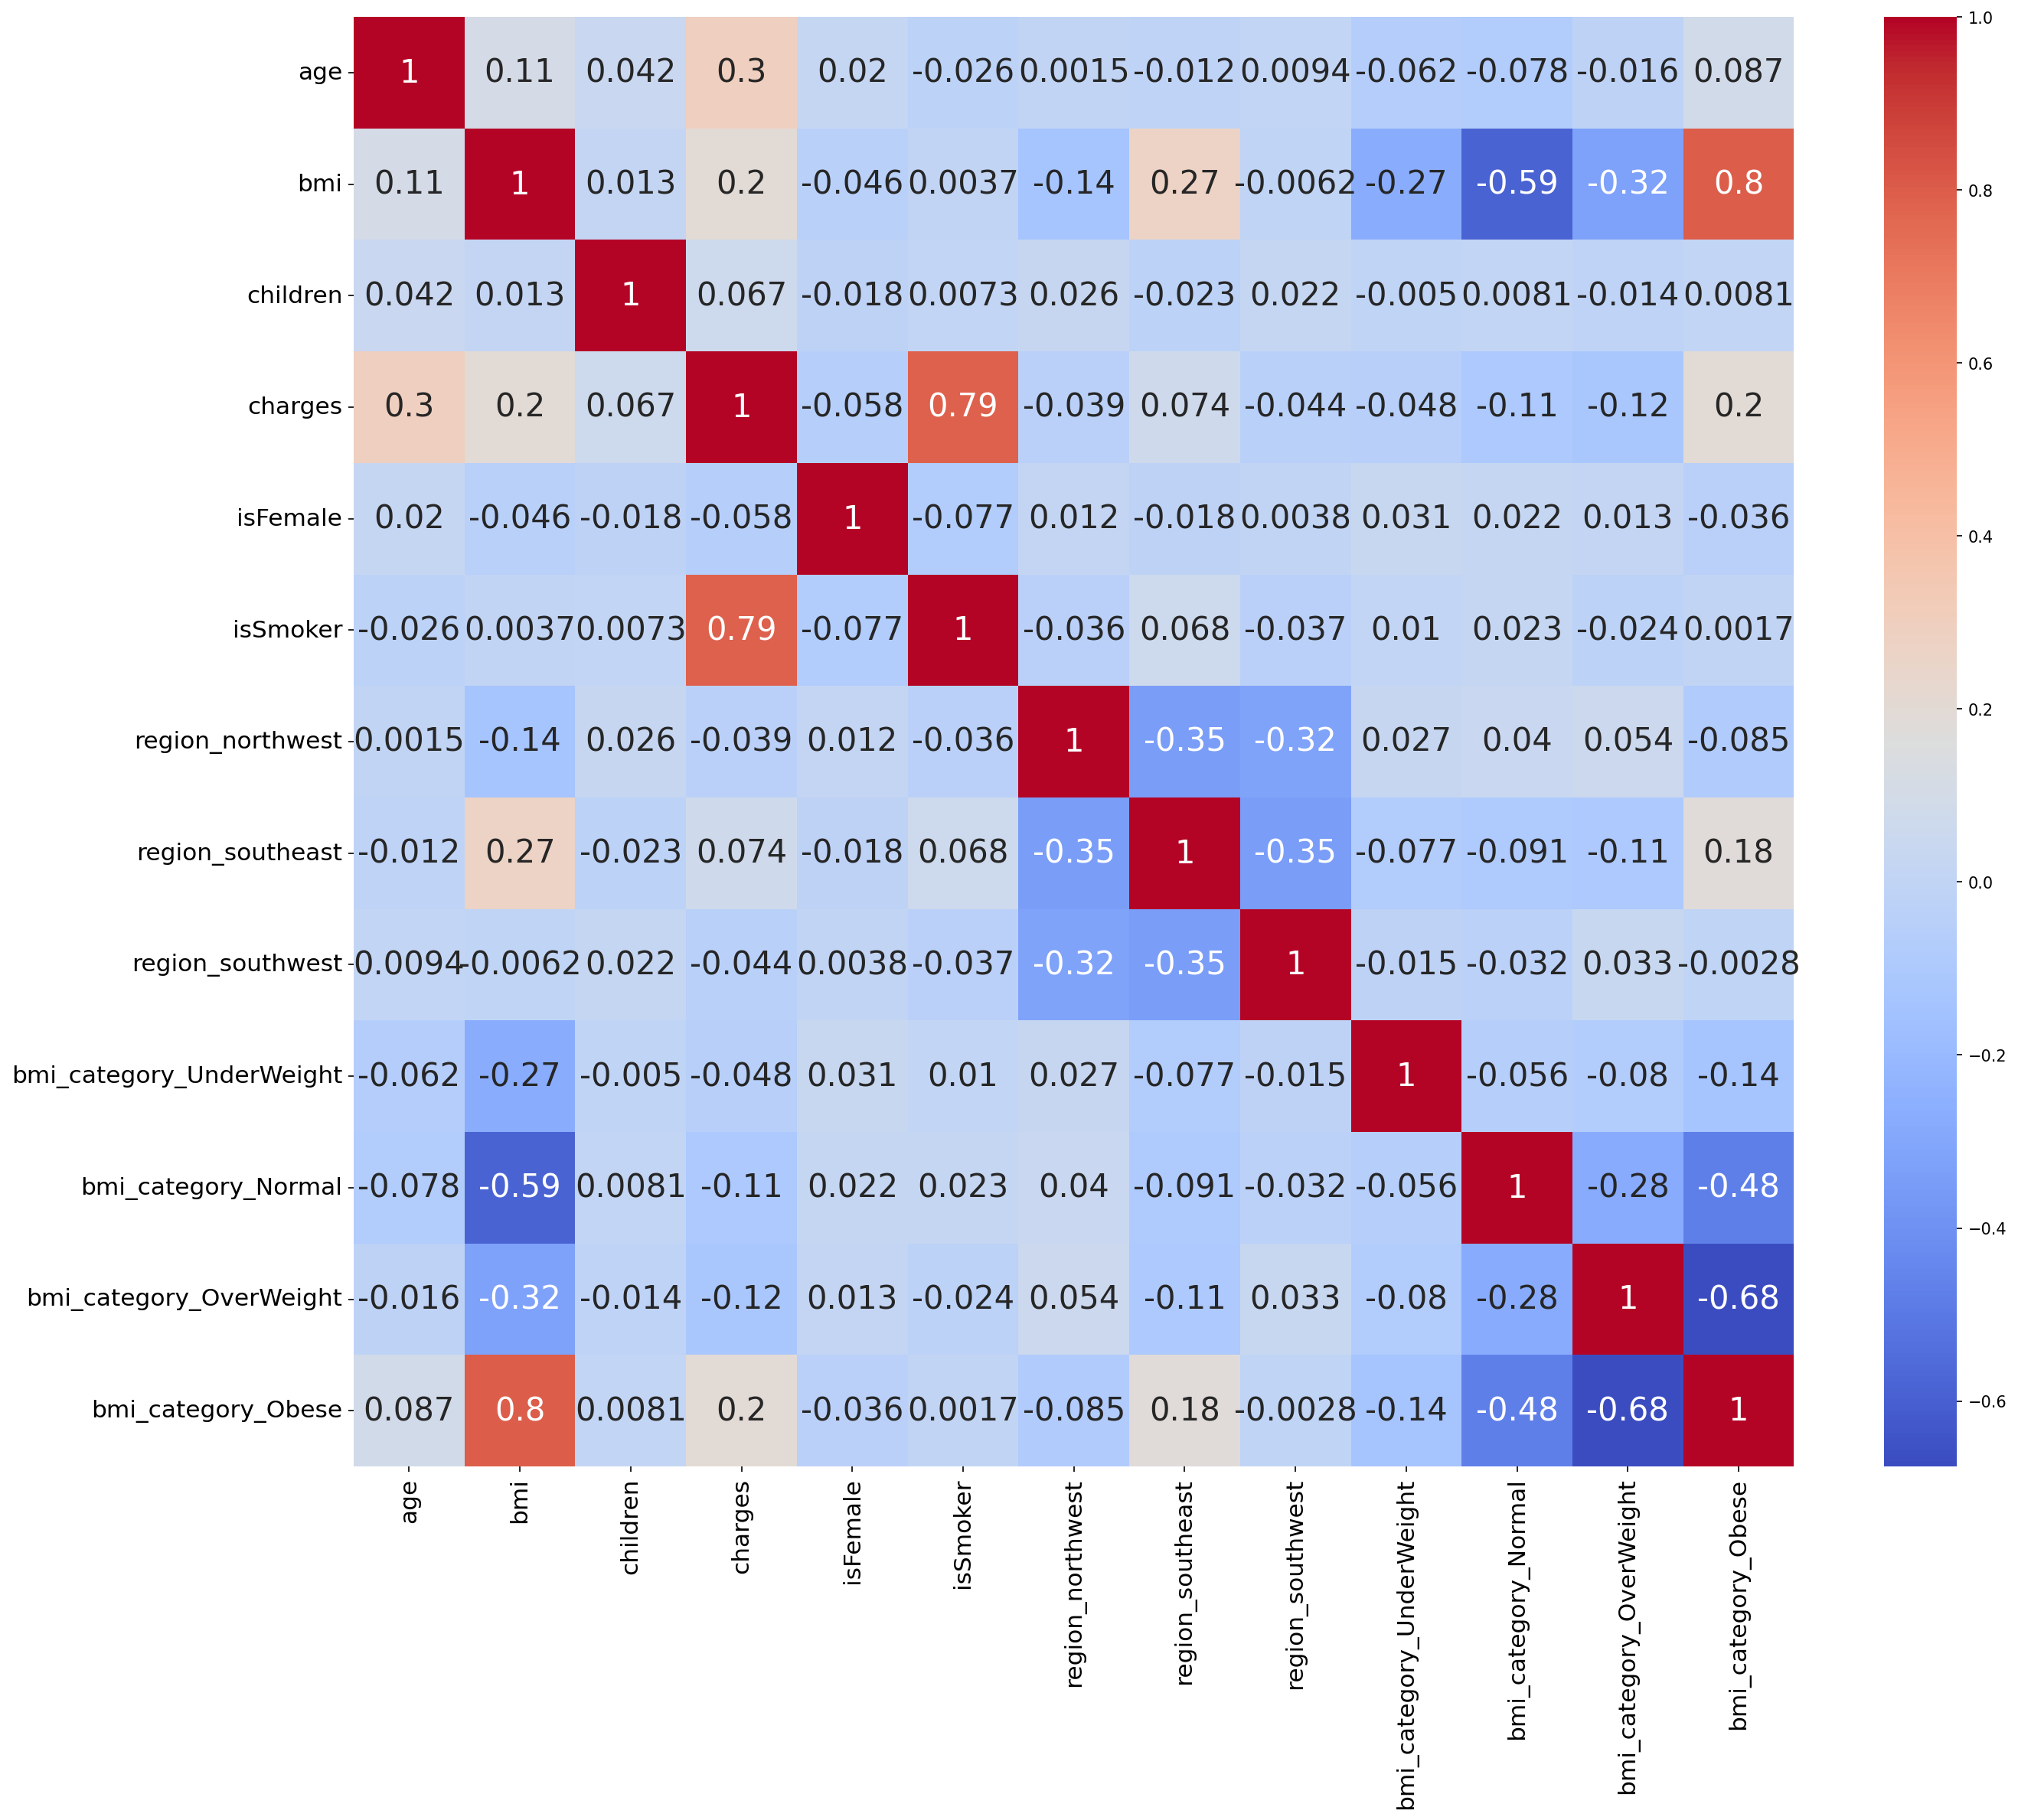

In [39]:
#feature extraction

plt.figure(figsize=(18,15),dpi=150)

sns.heatmap(
    data=df_clean.corr(),
    cmap='coolwarm',
    annot=True,
    annot_kws={"size":20}
)
plt.tight_layout()
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

In [48]:
cat_features=[
    'isFemale','isSmoker','region_northwest',
    'region_southeast','bmi_category_Normal',
    'bmi_category_OverWeight','bmi_category_Obese',
    'region_southwest'
]


In [52]:
from scipy.stats import chi2_contingency
df_clean=df_clean.astype('int')

alpha=0.05
df_clean['charges_bin']=pd.qcut(df_clean['charges'],q=4,labels=False) #create equal size bins
chi2_result={}

for col in cat_features:
    contingency=pd.crosstab(df_clean[col],df_clean['charges_bin'])
    chi2_stat,p_value,dof,expected=chi2_contingency(contingency)
    decision='Reject Null (Keep Feature)' if p_value<alpha else 'Accept Null (Drop Feature)'
    chi2_result[col]={
        'chi2_statistic':chi2_stat,
        'p_value':p_value,
        'Decision':decision
    }

chi2_df=pd.DataFrame(chi2_result).T
chi2_df=chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
isSmoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
isFemale,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obese,7.654464,0.05372,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Normal,4.263673,0.234364,Accept Null (Drop Feature)
bmi_category_OverWeight,4.201575,0.240504,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [53]:
final_df=df_clean[['age','isFemale','bmi','children','isSmoker','charges','region_southeast','bmi_category_Obese']]
final_df

,age,isFemale,bmi,children,isSmoker,charges,region_southeast,bmi_category_Obese
0,19,1,27,0,1,16884,0,0
1,18,0,33,1,0,1725,1,1
2,28,0,33,3,0,4449,1,1
3,33,0,22,0,0,21984,0,0
4,32,0,28,0,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1
1334,18,1,31,0,0,2205,0,1
1335,18,1,36,0,0,1629,1,1
1336,21,1,25,0,0,2007,0,0
